# Feature Engineering — Clasificación de Popularidad

## Decisión de modelo

Se elige **clasificación** sobre regresión por las siguientes razones:

| Criterio | Regresión | Clasificación |
|---|---|---|
| Observaciones | 168k pares, pero solo **4,596 jugadores únicos** | **98k juegos** con metadata completa |
| Sesgo de muestra | Solo jugadores con perfil público + historial de logros | Todos los juegos publicados en Steam |
| Features disponibles | Incompletas: muchos jugadores sin precio/reviews | Más completas por juego |
| Target | `n_logros_par` — sesgado por farming | `is_popular` — corregible con buen umbral |

**Pregunta de negocio:** *Dado un juego con sus características conocidas al momento de publicación (o poco después), ¿llegará al top 25% de juegos más comprados dentro de su categoría comparable?*

## Problema con el feature engineering original

El notebook original calculaba `is_popular = n_owners_public >= P75` sobre **todos los 98k juegos**, incluyendo playtests, juegos sin actividad y juegos sin ningún comprador registrado. El resultado fue un umbral de solo **25 dueños públicos** — prácticamente cualquier juego con algún comprador calificaba como 'popular'. Eso no es un target útil.

## Correcciones aplicadas aquí

1. **Filtro de universo válido** antes de calcular el target: se excluyen playtests, juegos sin precio ni categoría F2P conocida, y juegos sin ningún comprador.
2. **Target estratificado por género** (`is_popular_genre`): popular dentro de su categoría, no contra todo el catálogo.
3. **Features de leakage eliminadas**: `n_owners_public`, `n_owners_all`, `penetration_pct` no pueden usarse como features — son parte del target.
4. **Imputación explícita y justificada** para cada columna con faltantes.
5. **Feature adicional:** `days_since_release` como proxy de exposición temporal.
6. **Diagnóstico final** de la tabla maestra antes de exportar.

---
## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA = 'Datos/'

DARK_BG = '#0e1117'
CARD_BG = '#1a1f2e'
ACCENT1 = '#4f86f7'
ACCENT2 = '#7ee8a2'
ACCENT3 = '#ff6b6b'
ACCENT4 = '#ffd166'
TEXT    = '#e0e6f0'
MUTED   = '#8892a4'

plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': CARD_BG,
    'axes.edgecolor': MUTED,     'axes.labelcolor': TEXT,
    'xtick.color': MUTED,        'ytick.color': MUTED,
    'text.color': TEXT,          'grid.color': '#2d3348',
    'grid.alpha': 0.6,           'font.family': 'DejaVu Sans',
    'font.size': 11,
})

def title_ax(ax, txt, sub=None):
    ax.set_title(txt, fontsize=13, fontweight='bold', color=TEXT, pad=8)
    if sub:
        ax.text(0.5, 1.02, sub, transform=ax.transAxes,
                ha='center', fontsize=9, color=MUTED)

---
## Cargar CSVs exportados por los EDAs

In [2]:
games           = pd.read_csv(DATA + 'games_clean.csv', parse_dates=['release_date'])
ach_per_game    = pd.read_csv(DATA + 'achievements_per_game.csv')
prices_game     = pd.read_csv(DATA + 'prices_per_game.csv')
purchased_game  = pd.read_csv(DATA + 'purchased_per_game.csv')
reviews_game    = pd.read_csv(DATA + 'reviews_per_game.csv')
history_pair    = pd.read_csv(DATA + 'history_per_pair.csv')

print('CSVs cargados:')
for name, df in [
    ('games_clean',        games),
    ('ach_per_game',       ach_per_game),
    ('prices_per_game',    prices_game),
    ('purchased_per_game', purchased_game),
    ('reviews_per_game',   reviews_game),
    ('history_per_pair',   history_pair),
]:
    print(f'  {name:<22}: {df.shape[0]:>8,} filas x {df.shape[1]} cols')

CSVs cargados:
  games_clean           :   98,248 filas x 10 cols
  ach_per_game          :   50,537 filas x 6 cols
  prices_per_game       :   97,713 filas x 11 cols
  purchased_per_game    :   40,988 filas x 5 cols
  reviews_per_game      :   51,910 filas x 9 cols
  history_per_pair      :  253,610 filas x 3 cols


---
## 1. Construcción del universo válido de juegos

**Problema original:** el target `is_popular` se calculaba sobre los 98k juegos incluyendo playtests, juegos sin ningún comprador y juegos sin metadata. El P75 resultante era solo 25 dueños — prácticamente cualquier juego con algún comprador era 'popular'.

**Solución:** definir un universo de juegos 'evaluables' con criterios explícitos antes de calcular el target.

In [3]:
# Juegos con al menos un comprador público registrado
games_with_owners = purchased_game[purchased_game['n_owners_public'] > 0]['gameid']

# Universo válido: no playtest + tiene dueños + tiene género conocido
valid_games = games[
    (~games['is_playtest']) &
    (games['gameid'].isin(games_with_owners)) &
    (games['primary_genre'] != 'Unknown')
]['gameid']

print(f'Juegos totales en games_clean     : {len(games):>8,}')
print(f'  Excluidos — playtests           : {games["is_playtest"].sum():>8,}')
print(f'  Excluidos — sin dueños públicos : {len(games) - len(games_with_owners):>8,}  (aprox)')
print(f'  Excluidos — género Unknown      : {(games["primary_genre"]=="Unknown").sum():>8,}')
print(f'Universo válido final             : {len(valid_games):>8,}  ({len(valid_games)/len(games)*100:.1f}% del total)')

Juegos totales en games_clean     :   98,248
  Excluidos — playtests           :    5,294
  Excluidos — sin dueños públicos :   57,327  (aprox)
  Excluidos — género Unknown      :    5,549
Universo válido final             :   37,060  (37.7% del total)


---
## 2. Feature: avg_completion_rate por juego

Se calcula cruzando `history_per_pair` con `achievements_per_game`, **filtrando juegos spam y outliers** para que el ratio sea representativo de engagement real.

In [4]:
# Solo juegos legítimos (no spam, outlier_cat normal) para completion_rate confiable
ach_clean = ach_per_game[
    (~ach_per_game['is_spam_game']) &
    (ach_per_game['outlier_cat'] == 'normal')
][['gameid', 'n_achievements']]

history_cr = history_pair.merge(ach_clean, on='gameid', how='inner')
history_cr['completion_rate'] = (
    history_cr['n_logros_par'] / history_cr['n_achievements']
).clip(0, 1).round(4)

avg_cr = (
    history_cr
    .groupby('gameid')['completion_rate']
    .agg(avg_completion_rate='mean', n_players_with_history='count')
    .reset_index()
)

print(f'Pares con completion_rate válido : {len(history_cr):,} (de {len(history_pair):,} totales)')
print(f'Juegos con avg_completion_rate  : {len(avg_cr):,}')
print(f'completion_rate mediana         : {history_cr["completion_rate"].median():.3f}')

Pares con completion_rate válido : 168,552 (de 253,610 totales)
Juegos con avg_completion_rate  : 11,138
completion_rate mediana         : 0.222


---
## 3. Feature: is_f2p

Un juego es F2P si no tiene precio registrado pero sí tiene compradores públicos (alguien lo 'adquirió' aunque sea gratis).

In [5]:
F2P_MIN_OWNERS = 10  # umbral conservador para evitar falsos positivos

f2p = prices_game[['gameid', 'has_price']].merge(
    purchased_game[['gameid', 'n_owners_public']], on='gameid', how='outer'
)
f2p['has_price']       = f2p['has_price'].fillna(False)
f2p['n_owners_public'] = f2p['n_owners_public'].fillna(0)
f2p['is_f2p'] = (~f2p['has_price']) & (f2p['n_owners_public'] >= F2P_MIN_OWNERS)

print(f'is_f2p=True : {f2p["is_f2p"].sum():,} juegos')

is_f2p=True : 6,712 juegos


---
## 4. Ensamble de game_features

Se construye una tabla maestra con una fila por juego.

**IMPORTANTE:** `n_owners_public`, `n_owners_all` y `penetration_pct` se incluyen **solo para construir el target** y se eliminan antes de exportar la tabla de features.

In [6]:
SNAPSHOT_DATE = pd.Timestamp('2024-12-01')  # fecha de referencia del dataset

game_features = (
    games
    .merge(ach_per_game[['gameid', 'n_achievements', 'is_spam_game', 'spam_ratio',
                          'outlier_cat', 'pct_generic']],
           on='gameid', how='left')
    .merge(prices_game[['gameid', 'usd_latest', 'usd_log', 'price_tier',
                         'has_price', 'no_eur_region']],
           on='gameid', how='left')
    .merge(purchased_game[['gameid', 'n_owners_public', 'n_owners_all', 'penetration_pct']],
           on='gameid', how='left')
    .merge(reviews_game[['gameid', 'n_reviews', 'n_reviews_log', 'avg_helpful',
                          'avg_engagement', 'pct_with_text', 'avg_review_len']],
           on='gameid', how='left')
    .merge(avg_cr, on='gameid', how='left')
    .merge(f2p[['gameid', 'is_f2p']], on='gameid', how='left')
)

# Feature temporal: días desde lanzamiento hasta el snapshot del dataset
# Captura exposición acumulada del juego en el mercado
game_features['days_since_release'] = (
    SNAPSHOT_DATE - game_features['release_date']
).dt.days.clip(lower=0)

print(f'game_features shape: {game_features.shape}')
print(f'Faltantes por columna (top 15):')
miss = game_features.isnull().sum()
print(miss[miss > 0].sort_values(ascending=False).head(15))

game_features shape: (98248, 33)
Faltantes por columna (top 15):
avg_completion_rate       87153
n_players_with_history    87153
n_owners_all              61077
penetration_pct           61077
n_owners_public           61077
is_spam_game              47788
n_achievements            47788
spam_ratio                47788
pct_generic               47788
outlier_cat               47788
avg_engagement            46499
pct_with_text             46499
n_reviews_log             46499
avg_helpful               46499
n_reviews                 46499
dtype: int64


---
## 5. Filtrar al universo válido

Ahora restringimos a los juegos evaluables definidos en el paso 1.

In [7]:
df = game_features[game_features['gameid'].isin(valid_games)].copy().reset_index(drop=True)

print(f'Juegos en universo válido: {len(df):,}')
print(f'Distribución de n_owners_public:')
print(df['n_owners_public'].describe(percentiles=[.25, .5, .75, .90, .95, .99]).round(0))

Juegos en universo válido: 37,060
Distribución de n_owners_public:
count    37060.0
mean       234.0
std        683.0
min          1.0
25%         15.0
50%         64.0
75%        202.0
90%        516.0
95%        893.0
99%       2876.0
max      28434.0
Name: n_owners_public, dtype: float64


---
## 6. Construcción del target: `is_popular`

### Target global vs estratificado por género

El target original usaba el P75 global. El problema: géneros con distribuciones muy distintas (Indie vs AAA) hacen que el mismo umbral sea fácil de superar en un género y casi imposible en otro.

Se crean **dos versiones del target**:
- `is_popular_global`: P75 del universo completo (comparable con el original)
- `is_popular_genre`: P75 **dentro de su género** — más justo para modelar

In [8]:
# Target global
p75_global = df['n_owners_public'].quantile(0.75)
df['is_popular_global'] = (df['n_owners_public'] >= p75_global).astype(int)

# Target estratificado por género
df['p75_genre'] = df.groupby('primary_genre')['n_owners_public'].transform(
    lambda x: x.quantile(0.75)
)
df['is_popular_genre'] = (df['n_owners_public'] >= df['p75_genre']).astype(int)

print(f'Umbral P75 global           : {p75_global:,.0f} n_owners_public')
print(f'is_popular_global = 1       : {df["is_popular_global"].sum():,}  ({df["is_popular_global"].mean()*100:.1f}%)')
print(f'is_popular_genre  = 1       : {df["is_popular_genre"].sum():,}  ({df["is_popular_genre"].mean()*100:.1f}%)')
print()
print('P75 por género (top 10 géneros por volumen):')
genre_p75 = df.groupby('primary_genre').agg(
    n_juegos=('gameid', 'count'),
    p75_owners=('n_owners_public', lambda x: x.quantile(0.75)),
    pct_popular=('is_popular_genre', 'mean')
).sort_values('n_juegos', ascending=False).head(10)
print(genre_p75.round(1))

Umbral P75 global           : 202 n_owners_public
is_popular_global = 1       : 9,283  (25.0%)
is_popular_genre  = 1       : 9,307  (25.1%)

P75 por género (top 10 géneros por volumen):
               n_juegos  p75_owners  pct_popular
primary_genre                                   
Action            14739       255.0          0.3
Adventure          8602       179.0          0.3
Casual             5860       159.0          0.3
Indie              3530       159.0          0.3
Simulation         1064       161.0          0.3
RPG                 803       252.5          0.3
Strategy            698       313.8          0.3
Violent             324       135.0          0.3
Free To Play        263       320.0          0.3
Racing              261       277.0          0.3


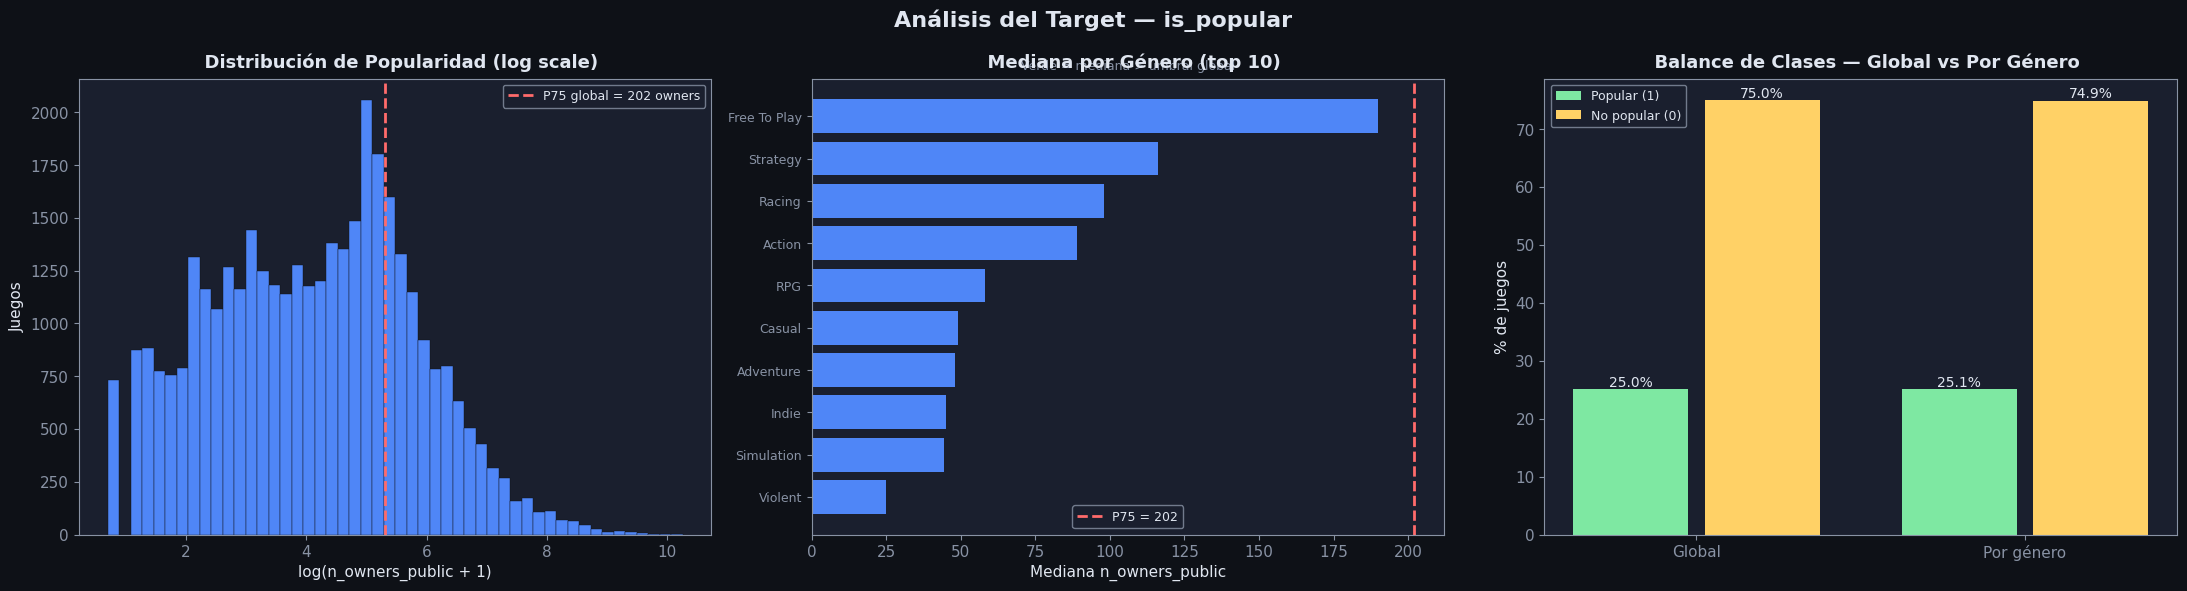

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Análisis del Target — is_popular', fontsize=16, fontweight='bold', color=TEXT)

ax = axes[0]
ax.hist(np.log1p(df['n_owners_public']), bins=50, color=ACCENT1, edgecolor=DARK_BG, linewidth=0.3)
ax.axvline(np.log1p(p75_global), color=ACCENT3, linewidth=2, linestyle='--',
           label=f'P75 global = {p75_global:.0f} owners')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('log(n_owners_public + 1)'); ax.set_ylabel('Juegos')
title_ax(ax, '  Distribución de Popularidad (log scale)')

ax = axes[1]
top_genres = df['primary_genre'].value_counts().head(10).index
genre_data = df[df['primary_genre'].isin(top_genres)]
genre_order = genre_data.groupby('primary_genre')['n_owners_public'].median().sort_values(ascending=False).index
medians = [genre_data[genre_data['primary_genre'] == g]['n_owners_public'].median() for g in genre_order]
colors_g = [ACCENT2 if v > p75_global else ACCENT1 for v in medians]
ax.barh(range(len(genre_order)), medians[::-1], color=colors_g[::-1])
ax.set_yticks(range(len(genre_order)))
ax.set_yticklabels(list(genre_order)[::-1], fontsize=9)
ax.axvline(p75_global, color=ACCENT3, linewidth=2, linestyle='--', label=f'P75 = {p75_global:.0f}')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Mediana n_owners_public')
title_ax(ax, '  Mediana por Género (top 10)', 'Verde = mediana > umbral global')

ax = axes[2]
target_compare = pd.DataFrame({
    'Global': [df['is_popular_global'].mean() * 100,
               (1 - df['is_popular_global'].mean()) * 100],
    'Por género': [df['is_popular_genre'].mean() * 100,
                   (1 - df['is_popular_genre'].mean()) * 100]
}, index=['Popular (1)', 'No popular (0)'])
x = np.arange(2)
ax.bar(x - 0.2, target_compare.iloc[0], width=0.35, color=ACCENT2, label='Popular (1)')
ax.bar(x + 0.2, target_compare.iloc[1], width=0.35, color=ACCENT4, label='No popular (0)')
for i, (v1, v2) in enumerate(zip(target_compare.iloc[0], target_compare.iloc[1])):
    ax.text(i - 0.2, v1 + 0.5, f'{v1:.1f}%', ha='center', fontsize=10, color=TEXT)
    ax.text(i + 0.2, v2 + 0.5, f'{v2:.1f}%', ha='center', fontsize=10, color=TEXT)
ax.set_xticks(x)
ax.set_xticklabels(['Global', 'Por género'])
ax.set_ylabel('% de juegos')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
title_ax(ax, '  Balance de Clases — Global vs Por Género')

plt.tight_layout()
plt.show()

---
## 7. Imputación de faltantes en features

Estrategia por columna justificada:

| Columna | Estrategia | Razón |
|---|---|---|
| `n_achievements`, `pct_generic`, `spam_ratio` | 0 | Juego sin logros registrados = 0 logros |
| `is_spam_game` | False | Sin evidencia de spam = no spam |
| `outlier_cat` | `'sin_logros'` | Categoría nueva que no confunde con 'normal' |
| `usd_log`, `usd_latest` | 0 | Sin precio = gratuito |
| `price_tier` | `'free_or_unknown'` | Categoría descriptiva |
| `has_price` | False | Sin precio registrado |
| `no_eur_region` | False | Asumir disponible salvo evidencia contraria |
| `is_f2p` | False | Completado por lógica de precio arriba |
| `n_reviews`, `avg_helpful`, `avg_engagement`, `pct_with_text`, `avg_review_len` | 0 / 0.0 | Sin reseñas = sin actividad |
| `n_reviews_log` | 0 | log1p(0) = 0 |
| `avg_completion_rate` | NaN → se imputará con mediana del género | Faltante real: no hay historial de jugadores |
| `n_players_with_history` | 0 | Sin jugadores con historial |
| `days_since_release` | 0 | Juego sin fecha = tratado como nuevo |

In [10]:
# Imputaciones directas
imputaciones = {
    'n_achievements': 0,
    'pct_generic': 0.0,
    'spam_ratio': 0.0,
    'is_spam_game': False,
    'usd_log': 0.0,
    'usd_latest': 0.0,
    'price_tier': 'free_or_unknown',
    'has_price': False,
    'no_eur_region': False,
    'is_f2p': False,
    'n_reviews': 0,
    'n_reviews_log': 0.0,
    'avg_helpful': 0.0,
    'avg_engagement': 0.0,
    'pct_with_text': 0.0,
    'avg_review_len': 0.0,
    'n_players_with_history': 0,
    'days_since_release': 0,
    'primary_genre': 'Unknown',
}

for col, val in imputaciones.items():
    if col in df.columns:
        n_antes = df[col].isna().sum()
        df[col] = df[col].fillna(val)
        if n_antes > 0:
            print(f'  {col:<30} : {n_antes:>6,} imputados con {repr(val)}')

# outlier_cat: categoría separada para juegos sin logros
if 'outlier_cat' in df.columns:
    n_antes = df['outlier_cat'].isna().sum()
    df['outlier_cat'] = df['outlier_cat'].fillna('sin_logros')
    print(f'  {"outlier_cat":<30} : {n_antes:>6,} imputados con "sin_logros"')

# avg_completion_rate: imputar con mediana del género
# (un juego sin historial asume el engagement promedio de su categoría)
n_antes = df['avg_completion_rate'].isna().sum()
genre_median_cr = df.groupby('primary_genre')['avg_completion_rate'].transform('median')
global_median_cr = df['avg_completion_rate'].median()
df['avg_completion_rate'] = df['avg_completion_rate'].fillna(genre_median_cr)
df['avg_completion_rate'] = df['avg_completion_rate'].fillna(global_median_cr)  # fallback
df['completion_rate_imputed'] = False  # flag: fue imputado
# Retroactivamente marcar cuáles fueron imputados
print(f'  {"avg_completion_rate":<30} : {n_antes:>6,} imputados con mediana del género')

print(f'\nFaltantes restantes: {df.isnull().sum().sum()}')

  n_achievements                 : 13,582 imputados con 0
  pct_generic                    : 13,582 imputados con 0.0
  spam_ratio                     : 13,582 imputados con 0.0
  is_spam_game                   : 13,582 imputados con False
  usd_log                        :  3,995 imputados con 0.0
  usd_latest                     :  3,995 imputados con 0.0
  price_tier                     :     11 imputados con 'free_or_unknown'
  has_price                      :     11 imputados con False
  no_eur_region                  :  3,995 imputados con False
  n_reviews                      :  7,864 imputados con 0
  n_reviews_log                  :  7,864 imputados con 0.0
  avg_helpful                    :  7,864 imputados con 0.0
  avg_engagement                 :  7,864 imputados con 0.0
  pct_with_text                  :  7,864 imputados con 0.0
  avg_review_len                 :  7,864 imputados con 0.0
  n_players_with_history         : 25,992 imputados con 0
  outlier_cat             

---
## 8. Construcción de la tabla maestra de clasificación

Se eliminan:
- `n_owners_public`, `n_owners_all`, `penetration_pct` → **leakage directo** (son el target)
- `p75_genre` → auxiliar de construcción
- Columnas de texto/ID no usables como features (`title`, `release_date`)
- `is_playtest` → ya filtrado (todos son False en este universo)

El **target recomendado** es `is_popular_genre` — evalúa popularidad dentro de la competencia directa del juego.

In [11]:
COLS_LEAKAGE = ['n_owners_public', 'n_owners_all', 'penetration_pct', 'p75_genre']
COLS_EXCLUIR = ['title', 'release_date', 'is_playtest']
COLS_TARGET  = ['is_popular_global', 'is_popular_genre']

feature_cols = [
    c for c in df.columns
    if c not in COLS_LEAKAGE + COLS_EXCLUIR + COLS_TARGET + ['gameid']
]

# Tabla final: gameid + features + targets
tabla_clasificacion = df[['gameid'] + feature_cols + COLS_TARGET].copy()

print(f'tabla_clasificacion: {tabla_clasificacion.shape}')
print(f'Features disponibles ({len(feature_cols)}):')
print(feature_cols)
print()
print(f'Target principal (is_popular_genre):')
print(f'  Positivos (popular)    : {tabla_clasificacion["is_popular_genre"].sum():,}  ({tabla_clasificacion["is_popular_genre"].mean()*100:.1f}%)')
print(f'  Negativos (no popular) : {(tabla_clasificacion["is_popular_genre"]==0).sum():,}  ({(tabla_clasificacion["is_popular_genre"]==0).mean()*100:.1f}%)')
print(f'Faltantes restantes: {tabla_clasificacion.isnull().sum().sum()}')

tabla_clasificacion: (37060, 30)
Features disponibles (27):
['release_year', 'primary_genre', 'genres_count', 'developers_count', 'publishers_count', 'supported_languages_count', 'n_achievements', 'is_spam_game', 'spam_ratio', 'outlier_cat', 'pct_generic', 'usd_latest', 'usd_log', 'price_tier', 'has_price', 'no_eur_region', 'n_reviews', 'n_reviews_log', 'avg_helpful', 'avg_engagement', 'pct_with_text', 'avg_review_len', 'avg_completion_rate', 'n_players_with_history', 'is_f2p', 'days_since_release', 'completion_rate_imputed']

Target principal (is_popular_genre):
  Positivos (popular)    : 9,307  (25.1%)
  Negativos (no popular) : 27,753  (74.9%)
Faltantes restantes: 0


---
## 9. Diagnóstico de la tabla maestra

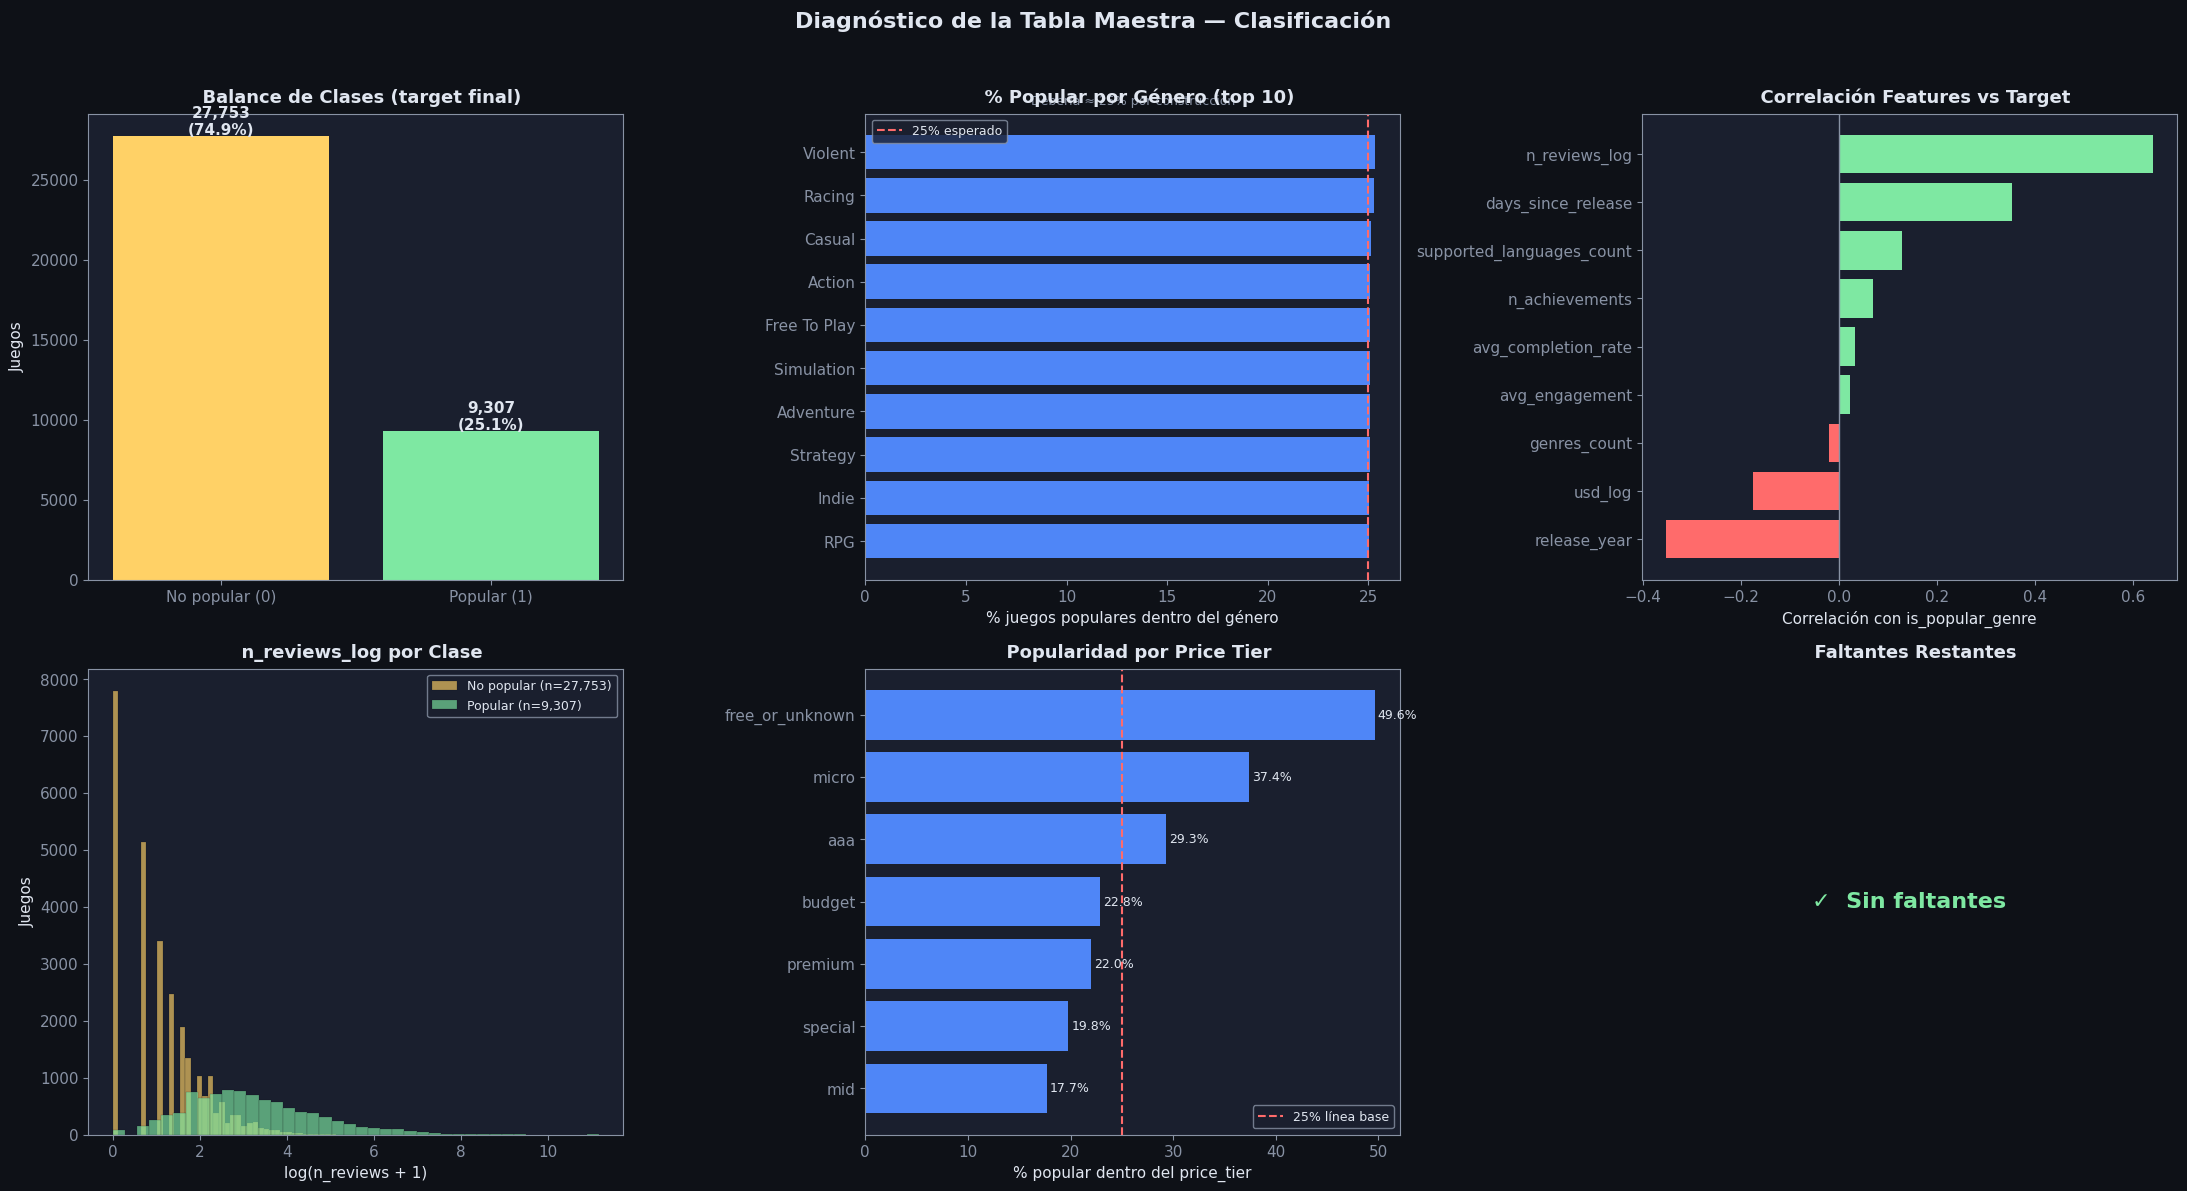

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Diagnóstico de la Tabla Maestra — Clasificación', fontsize=16, fontweight='bold', color=TEXT, y=0.99)

TARGET = 'is_popular_genre'

# 1. Distribución del target
ax = axes[0, 0]
vc = tabla_clasificacion[TARGET].value_counts()
ax.bar(['No popular (0)', 'Popular (1)'], [vc.get(0, 0), vc.get(1, 0)],
       color=[ACCENT4, ACCENT2])
for i, (label, val) in enumerate(zip(['No popular', 'Popular'], [vc.get(0, 0), vc.get(1, 0)])):
    ax.text(i, val + 50, f'{val:,}\n({val/len(tabla_clasificacion)*100:.1f}%)',
            ha='center', fontsize=11, color=TEXT, fontweight='bold')
ax.set_ylabel('Juegos')
title_ax(ax, '  Balance de Clases (target final)')

# 2. Popularidad por género
ax = axes[0, 1]
top10g = tabla_clasificacion['primary_genre'].value_counts().head(10).index
pop_by_genre = (
    tabla_clasificacion[tabla_clasificacion['primary_genre'].isin(top10g)]
    .groupby('primary_genre')[TARGET].mean() * 100
).sort_values(ascending=True)
ax.barh(pop_by_genre.index, pop_by_genre.values, color=ACCENT1)
ax.axvline(25, color=ACCENT3, linewidth=1.5, linestyle='--', label='25% esperado')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('% juegos populares dentro del género')
title_ax(ax, '  % Popular por Género (top 10)', 'Debería ≈ 25% por construcción')

# 3. Correlación features numéricas vs target
ax = axes[0, 2]
num_cols = ['release_year', 'genres_count', 'supported_languages_count',
            'n_achievements', 'usd_log', 'n_reviews_log',
            'avg_engagement', 'avg_completion_rate', 'days_since_release']
num_cols = [c for c in num_cols if c in tabla_clasificacion.columns]
corrs = tabla_clasificacion[num_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
colors_c = [ACCENT3 if v < 0 else ACCENT2 for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors_c)
ax.axvline(0, color=MUTED, linewidth=1)
ax.set_xlabel('Correlación con is_popular_genre')
title_ax(ax, '  Correlación Features vs Target')

# 4. Distribución de n_reviews_log por clase
ax = axes[1, 0]
for val, color, label in [(0, ACCENT4, 'No popular'), (1, ACCENT2, 'Popular')]:
    data = tabla_clasificacion[tabla_clasificacion[TARGET] == val]['n_reviews_log']
    ax.hist(data, bins=40, alpha=0.65, color=color, edgecolor=DARK_BG,
            linewidth=0.2, label=f'{label} (n={len(data):,})')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('log(n_reviews + 1)'); ax.set_ylabel('Juegos')
title_ax(ax, '  n_reviews_log por Clase')

# 5. price_tier por clase
ax = axes[1, 1]
pt_pop = tabla_clasificacion.groupby('price_tier')[TARGET].mean() * 100
pt_n   = tabla_clasificacion.groupby('price_tier').size()
pt_order = pt_pop.sort_values(ascending=True)
bars = ax.barh(pt_order.index, pt_order.values, color=ACCENT1)
for bar, val in zip(bars, pt_order.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, color=TEXT)
ax.axvline(25, color=ACCENT3, linewidth=1.5, linestyle='--', label='25% línea base')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('% popular dentro del price_tier')
title_ax(ax, '  Popularidad por Price Tier')

# 6. Faltantes restantes
ax = axes[1, 2]
miss_final = tabla_clasificacion.isnull().sum()
miss_final = miss_final[miss_final > 0]
if len(miss_final) > 0:
    ax.barh(miss_final.index, miss_final.values, color=ACCENT3)
    ax.set_xlabel('Faltantes')
    title_ax(ax, '  Faltantes Restantes')
else:
    ax.text(0.5, 0.5, '✓  Sin faltantes', ha='center', va='center',
            transform=ax.transAxes, fontsize=16, color=ACCENT2, fontweight='bold')
    ax.axis('off')
    title_ax(ax, '  Faltantes Restantes')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---
## 10. Resumen de features y recomendaciones para el modelo

In [13]:
print('═' * 65)
print('  RESUMEN — Tabla Maestra de Clasificación')
print('═' * 65)
print(f'  Juegos totales            : {len(tabla_clasificacion):>8,}')
print(f'  Features                  : {len(feature_cols):>8}')
print(f'  Target: is_popular_genre')
print(f'    Populares (1)           : {tabla_clasificacion["is_popular_genre"].sum():>8,}  ({tabla_clasificacion["is_popular_genre"].mean()*100:.1f}%)')
print(f'    No populares (0)        : {(tabla_clasificacion["is_popular_genre"]==0).sum():>8,}  ({(tabla_clasificacion["is_popular_genre"]==0).mean()*100:.1f}%)')
print(f'  Faltantes totales         : {tabla_clasificacion.isnull().sum().sum():>8,}')
print('═' * 65)
print()
print('FEATURES CATEGÓRICAS (requieren encoding):')
cat_cols = tabla_clasificacion[feature_cols].select_dtypes(include='object').columns.tolist()
for c in cat_cols:
    print(f'  {c:<30} : {tabla_clasificacion[c].nunique()} valores únicos')
print()
print('FEATURES NUMÉRICAS:')
num_cols_all = tabla_clasificacion[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols_all:
    print(f'  {c}')
print()
print('RECOMENDACIONES PARA EL MODELO:')
print('  1. Usar is_popular_genre como target (más balanceado y justo por categoría)')
print('  2. Probar XGBoost / LightGBM — manejan bien categóricas y valores cero')
print('  3. Encodear primary_genre con target encoding (alta cardinalidad relativa)')
print('  4. price_tier y outlier_cat con one-hot encoding')
print('  5. Considerar eliminar completion_rate_imputed si el modelo lo ignora')
print('  6. Validar con stratified k-fold por primary_genre')

═════════════════════════════════════════════════════════════════
  RESUMEN — Tabla Maestra de Clasificación
═════════════════════════════════════════════════════════════════
  Juegos totales            :   37,060
  Features                  :       27
  Target: is_popular_genre
    Populares (1)           :    9,307  (25.1%)
    No populares (0)        :   27,753  (74.9%)
  Faltantes totales         :        0
═════════════════════════════════════════════════════════════════

FEATURES CATEGÓRICAS (requieren encoding):
  primary_genre                  : 27 valores únicos
  outlier_cat                    : 4 valores únicos
  price_tier                     : 7 valores únicos

FEATURES NUMÉRICAS:
  release_year
  genres_count
  developers_count
  publishers_count
  supported_languages_count
  n_achievements
  spam_ratio
  pct_generic
  usd_latest
  usd_log
  n_reviews
  n_reviews_log
  avg_helpful
  avg_engagement
  pct_with_text
  avg_review_len
  avg_completion_rate
  n_players_with_his

---
## 11. Exportar

In [14]:
tabla_clasificacion.to_csv(DATA + 'tabla_clasificacion.csv', index=False)

print('Exportado:')
print(f'  tabla_clasificacion.csv : {tabla_clasificacion.shape[0]:,} x {tabla_clasificacion.shape[1]}')
print()
print('Columnas:')
print(list(tabla_clasificacion.columns))

Exportado:
  tabla_clasificacion.csv : 37,060 x 30

Columnas:
['gameid', 'release_year', 'primary_genre', 'genres_count', 'developers_count', 'publishers_count', 'supported_languages_count', 'n_achievements', 'is_spam_game', 'spam_ratio', 'outlier_cat', 'pct_generic', 'usd_latest', 'usd_log', 'price_tier', 'has_price', 'no_eur_region', 'n_reviews', 'n_reviews_log', 'avg_helpful', 'avg_engagement', 'pct_with_text', 'avg_review_len', 'avg_completion_rate', 'n_players_with_history', 'is_f2p', 'days_since_release', 'completion_rate_imputed', 'is_popular_global', 'is_popular_genre']


---
## Decisiones tomadas en este notebook

| Decisión | Justificación |
|---|---|
| **Clasificación sobre regresión** | El dataset de regresión solo tiene 4,596 jugadores únicos de 424k — muestra pequeña y sesgada. La clasificación trabaja con todos los juegos. |
| **Filtro de universo válido antes del target** | El P75 original sobre 98k juegos resultaba en solo 25 dueños. Filtrar playtests y juegos sin actividad eleva el umbral a un valor significativo. |
| **Target estratificado por género** | Géneros con distribuciones muy distintas (Indie masivo vs nicho de estrategia) hacen injusta la comparación global. El modelo aprende dentro de la competencia directa. |
| **Eliminación de leakage** | `n_owners_public`, `n_owners_all`, `penetration_pct` no pueden ser features — son el target o están directamente correlacionadas con él. |
| **`days_since_release`** | Feature nueva que captura exposición acumulada del juego. Un juego de 2015 tuvo más tiempo de acumular compradores que uno de 2024. |
| **Imputación de `avg_completion_rate` con mediana del género** | Los juegos sin historial de logros no deben recibir 0 (que distorsionaría hacia abajo) sino el engagement promedio de juegos similares. |
| **`outlier_cat = 'sin_logros'` en lugar de 'normal'** | Evita confundir juegos sin logros registrados con juegos que tienen logros en rango normal. Son categorías distintas. |